In [1]:
from util import go_to_project_root
go_to_project_root()

CWD changed to the project root: /home/epsilon/Documents/doctorado/S2/ENSTA630/tareas/HW1


# Pregunta 3

In [2]:
import numpy as np
import matplotlib.pyplot as plt 

from source.models.arma import ARMA
from source.utils import plot as uplot 
from source.data.loaders import create_dataset
from source.optimize.conditionalss import conditional_square_sum
from source.optimize.likelihood import maximum_likelihood_estimation
from source.optimize.boostrap import parametric_bootstrap_hr

%load_ext autoreload
%autoreload 2

## Analisis exploratorio

El archivo `base_25.xls` contiene información mensual del 
- IPC (P), 
- IMACEC (Y), 
- Tasa de Política Monetaria (I). 

La funcion `create_dataset` lee los datos y transforma cada serie segun las siguintes definiciones: 
- $\pi_t = \ln(P_t/P_{t-1})$ (Tasa de cambio del IPC) 
- $y_t = \ln(Y_t/Y_{t-1})$ (Tasa de cambio del IMACEC)
- $i_t = I_t/100$. (Tasa de politica monetaria)

In [3]:
dataset = create_dataset('./data/base_25.xls')
dataset.keys()

[INFO] Data loaded successfully!


dict_keys(['t', 'pi_t', 'y_t', 'i_t'])

### Evaluando estacionalidad

Para evaluar estacionalidad utilizaremos 3 enfoques: 
1. Inspeccion visual de la serie de tiempo 
2. Inspeccion visual de la Funcion de Autocorrelacion (ACF) y Funcion de Autocorrelacion Parcial (PACF)
3. Analisis de medidas de tendencia central

Partimos por observar las series de tiempo, 

✅ Successfully saved figure to ./presentation/figures/p3/raw_series.pdf


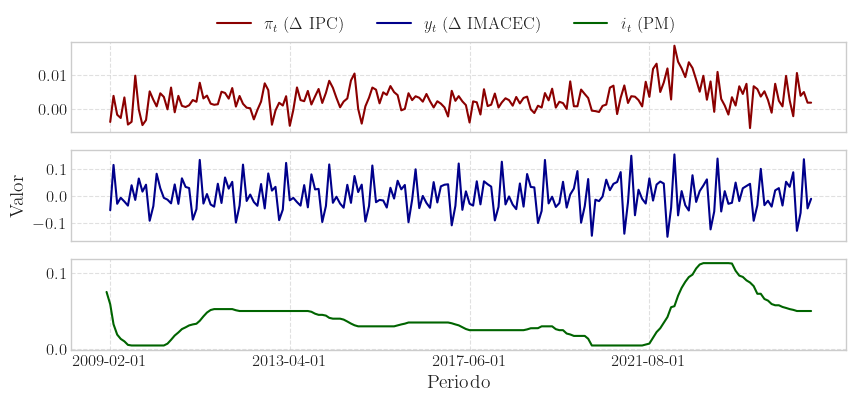

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(10, 4), sharex=True)
fig, axes = uplot.plot_series_p3(dataset, fig, axes)
uplot.save_figure(fig, './presentation/figures/p3/raw_series.pdf')

A simple vista podemos ver que la tasa de cambio del IMACEC exhibe peaks periodicos, potencialmente patrones estacionales. 

##### ACF y PACF en la Inflacion $(\pi_t)$

✅ Successfully saved figure to ./presentation/figures/p3/acf_pacf_ipc.pdf


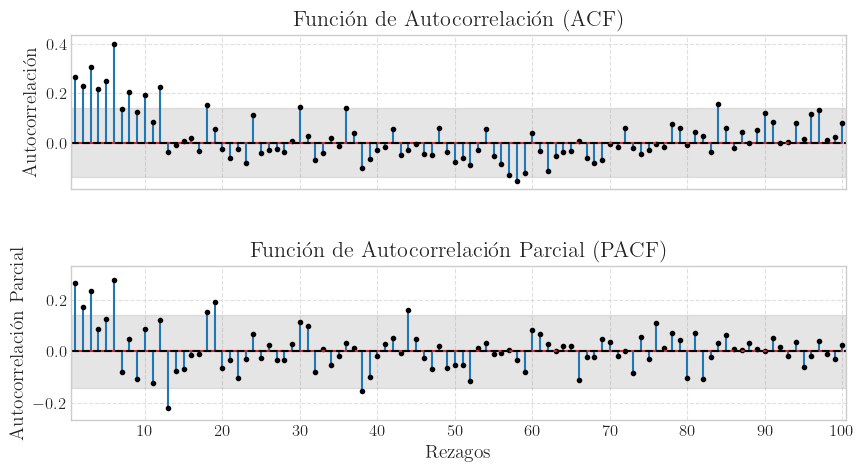

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True, gridspec_kw={'hspace':0.5})
fig, axes = uplot.plot_acf_pacf(dataset['pi_t'], lags= 100, fig=fig, axes=axes)
uplot.save_figure(fig, './presentation/figures/p3/acf_pacf_ipc.pdf')

Al observar la figura podemos ver que no existen patrones significativos que permitan afirmar una estacionalidad evidente. Sin embargo desde la ACF se desprende que aproximadamente hasta el rezago 20 se tiene una autocorrelacion significativa entre las obervaciones. Lo anterior se confirma con el PACF el cual muestra los rezagos ajustados desde un AR truncado. Como se puede ver en la iamgen los valores significativos comprenden un rango menor que 20

##### ACF y PACF en el IMACEC

✅ Successfully saved figure to ./presentation/figures/p3/acf_pacf_imacec.pdf


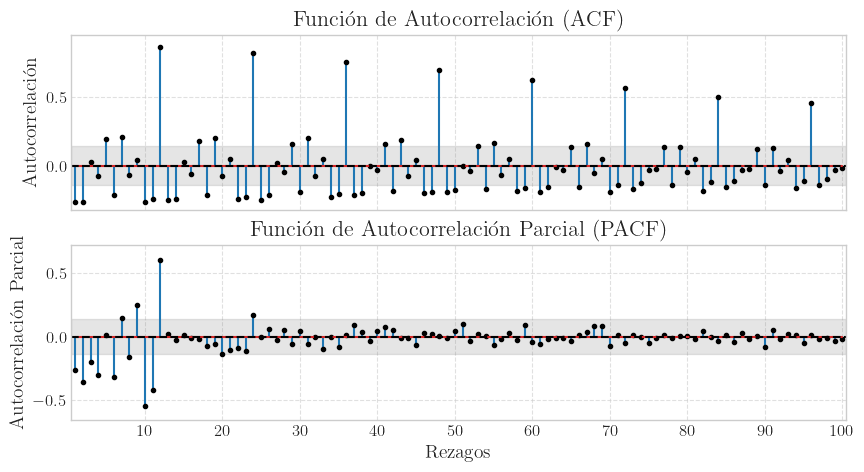

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
fig, axes = uplot.plot_acf_pacf(dataset['y_t'], lags= 100, fig=fig, axes=axes)
uplot.save_figure(fig, './presentation/figures/p3/acf_pacf_imacec.pdf')

Desde el ACF se ve una estacionalidad significativa cada $\sim 12$ rezagos. 

Desde el PACF podemos observar que hasta el rezago $\sim 12$ existe significancia de correlacion despues de haber contorolado por los rezagos anteriores. 

##### ACF y PACF en la Tasa de Politica Monetaria ($i_t$)

✅ Successfully saved figure to ./presentation/figures/p3/acf_pacf_tpm.pdf


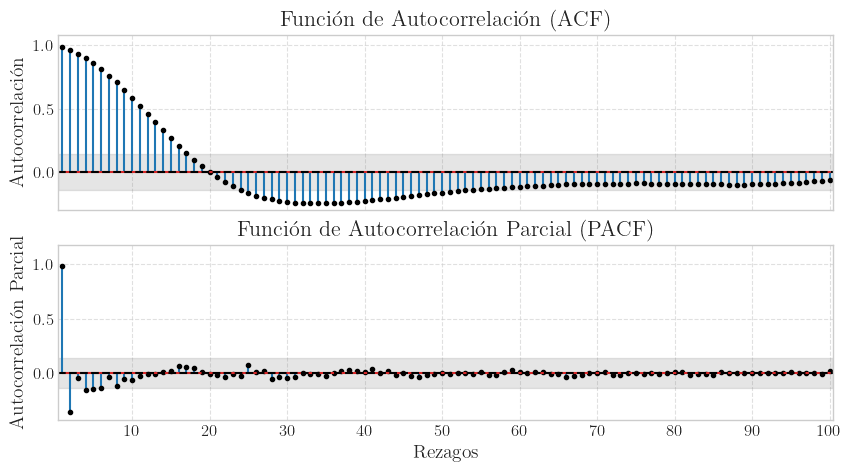

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
fig, axes = uplot.plot_acf_pacf(dataset['i_t'], lags= 100, fig=fig, axes=axes)
uplot.save_figure(fig, './presentation/figures/p3/acf_pacf_tpm.pdf')

La ACF para la tasa de politica monetaria muestra un decaimiento muy lento y gradual. Esto indica que el proceso es altamente no estacionario, y con alta persistencia. En otras palabras, el valor de la TPM en un periodo esta fuertemente correlacionado con sus valores en periodos anteriores. Una decisión de política monetaria de hoy tiene efectos duraderos en el futuro lo cual impidie que la tasa revierta a un promedio historico.

Desde la PACF vemos un pico muy grande en el primer rezago y un efecto negativo en el segundo, pero de menor magnitud. Esto sugiere que el proceso es similar a un $AR(\sim 1)$ donde el valor del futuro depende altamente del periodo inmediatamente anterior y los otros valores son irrelevantes para el valor actual.

/home/epsilon/Documents/doctorado/S2/ENSTA630/tareas/HW1/source/utils/plot.py:277: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(month_names, fontsize=FONT_SIZES['tick'])


✅ Successfully saved figure to ./presentation/figures/p3/med_ipc.pdf


/home/epsilon/Documents/doctorado/S2/ENSTA630/tareas/HW1/source/utils/plot.py:277: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(month_names, fontsize=FONT_SIZES['tick'])


✅ Successfully saved figure to ./presentation/figures/p3/med_imacec.pdf


/home/epsilon/Documents/doctorado/S2/ENSTA630/tareas/HW1/source/utils/plot.py:277: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(month_names, fontsize=FONT_SIZES['tick'])


✅ Successfully saved figure to ./presentation/figures/p3/med_tpm.pdf


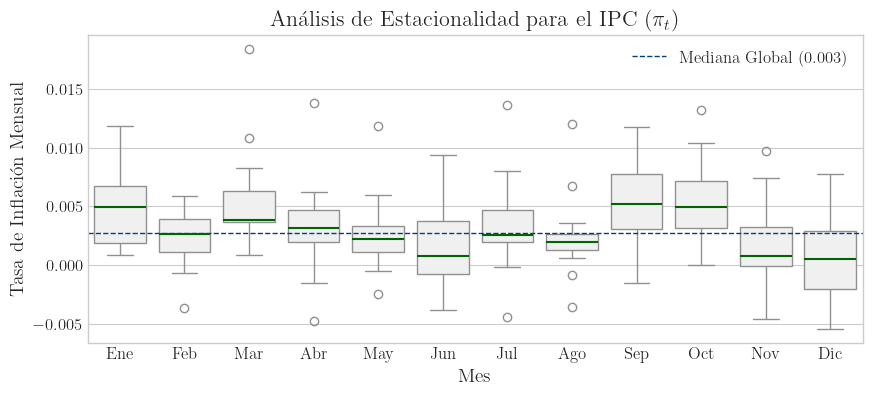

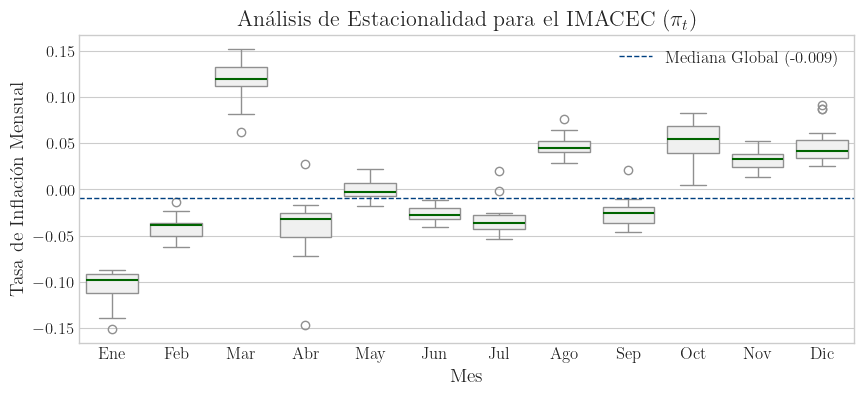

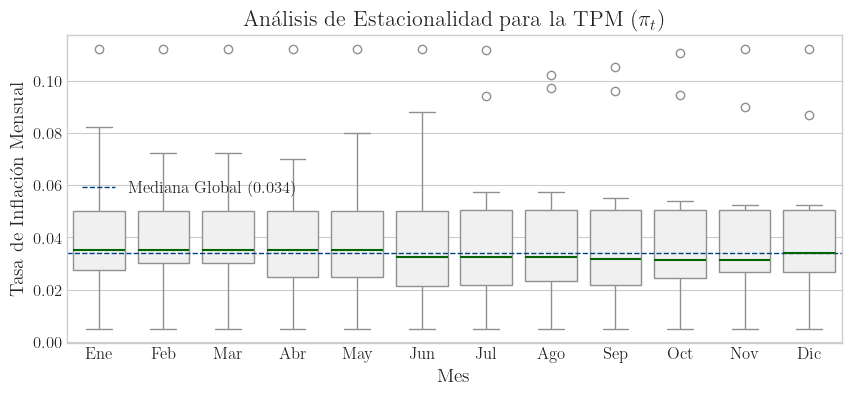

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
uplot.plot_monthly_boxplot(dataset['t'][1:], dataset['pi_t'], 
                           title=r'Análisis de Estacionalidad para el IPC ($\pi_t$)',
                           ylabel='Tasa de Inflación Mensual',
                           fig=fig, ax=ax)
uplot.save_figure(fig, './presentation/figures/p3/med_ipc.pdf')
fig, ax = plt.subplots(figsize=(10, 4))
uplot.plot_monthly_boxplot(dataset['t'][1:], dataset['y_t'], 
                           title=r'Análisis de Estacionalidad para el IMACEC ($\pi_t$)',
                           ylabel='Tasa de Inflación Mensual',
                           fig=fig, ax=ax)
uplot.save_figure(fig, './presentation/figures/p3/med_imacec.pdf')

fig, ax = plt.subplots(figsize=(10, 4))
uplot.plot_monthly_boxplot(dataset['t'], dataset['i_t'], 
                           title=r'Análisis de Estacionalidad para la TPM ($\pi_t$)',
                           ylabel='Tasa de Inflación Mensual',
                           fig=fig, ax=ax)
uplot.save_figure(fig, './presentation/figures/p3/med_tpm.pdf')

#### Determinando el p y q

Desde el procedimiento anterior podemos decir que los valores para $p$ y $q$ oscilan entre los 0 y 15 rezagos. Sin embargo, para evaluar correctamente utilizaremos el metodo Hannan Rissanen.

In [12]:
from source.optimize.parallel import parallel_bootstrap_hr

criteria = 'hqic'
results_ipc = parallel_bootstrap_hr(dataset['pi_t'], 
                                    iterations=100, 
                                    j_max=20, 
                                    criteria=criteria,
                                    n_jobs=8)

results_imacec = parallel_bootstrap_hr(dataset['y_t'], 
                                    iterations=100, 
                                    j_max=20, 
                                    criteria=criteria,
                                    n_jobs=8)

results_tpm = parallel_bootstrap_hr(dataset['i_t'], 
                                    iterations=100, 
                                    j_max=20, 
                                    criteria=criteria,
                                    n_jobs=8)

Iniciando Bootstrap con 100 iteraciones...


Procesando iteraciones:   0%|          | 0/100 [00:00<?, ?it/s]

Procesando iteraciones: 100%|██████████| 100/100 [00:09<00:00, 10.28it/s]



Par más estable: (6,0) [51/100 veces]
Reajustando el modelo final a los datos originales...
Iniciando Bootstrap con 100 iteraciones...


Procesando iteraciones: 100%|██████████| 100/100 [02:32<00:00,  1.52s/it]



Par más estable: (13,0) [37/100 veces]
Reajustando el modelo final a los datos originales...
Iniciando Bootstrap con 100 iteraciones...


Procesando iteraciones: 100%|██████████| 100/100 [01:05<00:00,  1.54it/s]



Par más estable: (6,0) [45/100 veces]
Reajustando el modelo final a los datos originales...


In [13]:
results_imacec

{'best_p': 13,
 'best_q': 0,
 'model': <source.models.arma.ARMA at 0x711166f000b0>,
 'param_distribution':        (p,q)  frequency  probability
 0    (13, 0)         37         0.37
 1   (12, 13)         15         0.15
 2    (15, 5)         15         0.15
 3    (13, 4)         14         0.14
 4   (12, 12)          9         0.09
 5    (13, 5)          2         0.02
 6   (18, 13)          2         0.02
 7   (19, 13)          2         0.02
 8    (19, 6)          2         0.02
 9    (18, 2)          1         0.01
 10  (19, 10)          1         0.01}

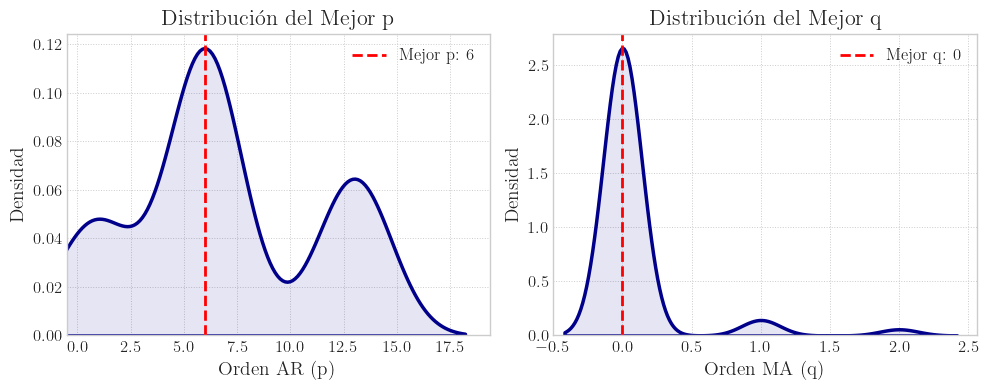

✅ Successfully saved figure to ./presentation/figures/p3/pq_hqic_ipc.pdf


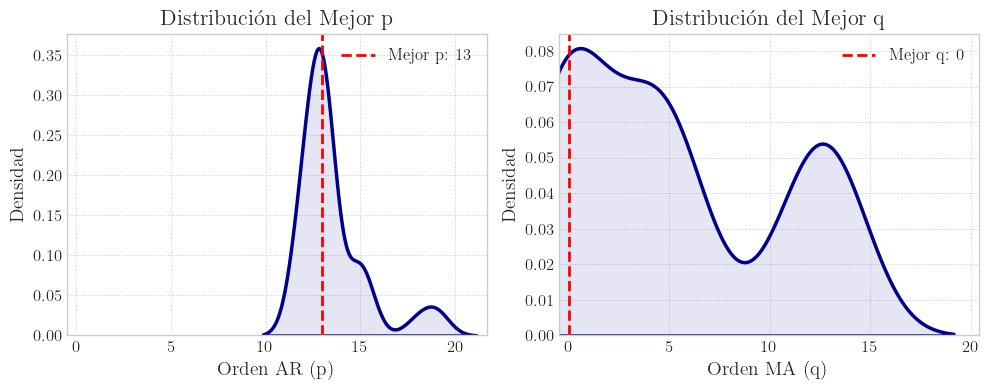

✅ Successfully saved figure to ./presentation/figures/p3/pq_hqic_imacec.pdf


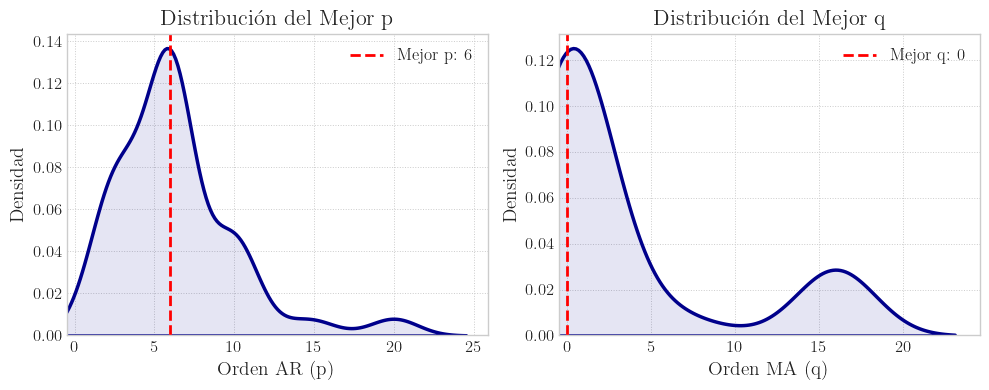

✅ Successfully saved figure to ./presentation/figures/p3/pq_hqic_tpm.pdf


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig, axes = uplot.plot_bootstrap_kde(results_ipc, fig=fig, axes=axes)
uplot.save_figure(fig, './presentation/figures/p3/pq_{}_ipc.pdf'.format(criteria))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig, axes = uplot.plot_bootstrap_kde(results_imacec, fig=fig, axes=axes)
uplot.save_figure(fig, './presentation/figures/p3/pq_{}_imacec.pdf'.format(criteria))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig, axes = uplot.plot_bootstrap_kde(results_tpm, fig=fig, axes=axes)
uplot.save_figure(fig, './presentation/figures/p3/pq_{}_tpm.pdf'.format(criteria))

KeyError: 'freq_p'

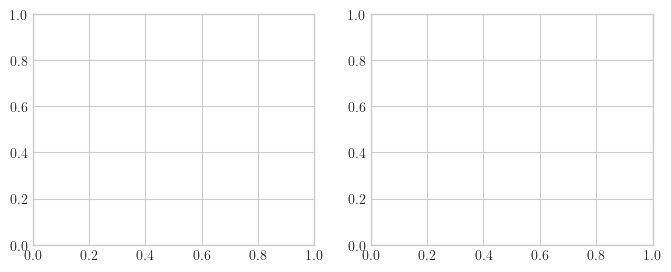

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
fig, axes = uplot.plot_hannan_rissanen_results(results=results_ipc, 
                                               fig=fig, 
                                               axes=axes)
uplot.save_figure(fig, './presentation/figures/p3/pq_ipc.pdf')

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
fig, axes = uplot.plot_hannan_rissanen_results(results=results_imacec, 
                                               fig=fig, 
                                               axes=axes)
uplot.save_figure(fig, './presentation/figures/p3/pq_imacec.pdf')

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
fig, axes = uplot.plot_hannan_rissanen_results(results=results_tpm, 
                                               fig=fig, 
                                               axes=axes)
uplot.save_figure(fig, './presentation/figures/p3/pq_tpm.pdf')

In [24]:
results_tpm['model'].phi, results_tpm['model'].theta

(array([ 1.78489404, -1.07901169,  0.39374229, -0.78670627,  0.69438916,
         0.34037411, -0.27654946, -0.15802469, -0.36929207,  0.91811765,
        -0.51819575]),
 array([-0.5375709 ,  0.41095065, -0.04593561,  0.9704793 ,  0.54281595,
        -0.20623932,  0.2229162 ,  0.0274717 ,  1.16820003, -0.49706967,
         0.13310865,  0.07356459,  0.26770277,  0.24642233, -0.15730594,
         0.0179999 ,  0.18601465]))

In [25]:
print(results_ipc['model'])

             ARMA(6, 0) Model Summary             
Is Stationary            : True
Mu (Unc. Mean)           : 0.0036
Sigma (Unc. Std.)        : 1.2258
Error Std Dev (sigma)    : 0.0033
Constant (c)             : 0.0010
--------------------------------------------------
AR Coefficients (phi):
  phi_1    = 0.1176
  phi_2    = 0.0446
  phi_3    = 0.1207
  phi_4    = 0.0599
  phi_5    = 0.0709
  phi_6    = 0.2962
--------------------------------------------------
MA Coefficients (theta):
  (No MA coefficients)


In [26]:
print(results_imacec['model'])

            ARMA(13, 0) Model Summary             
Is Stationary            : True
Mu (Unc. Mean)           : 0.0023
Sigma (Unc. Std.)        : nan
Error Std Dev (sigma)    : 0.0217
Constant (c)             : 0.0037
--------------------------------------------------
AR Coefficients (phi):
  phi_1    = -0.0157
  phi_2    = -0.2161
  phi_3    = -0.1172
  phi_4    = -0.1635
  phi_5    = -0.0642
  phi_6    = -0.1423
  phi_7    = -0.0363
  phi_8    = -0.1104
  phi_9    = -0.0494
  phi_10   = -0.1735
  phi_11   = -0.1256
  phi_12   = 0.7384
  phi_13   = -0.1370
--------------------------------------------------
MA Coefficients (theta):
  (No MA coefficients)


In [27]:
print(results_tpm['model'])

            ARMA(11, 17) Model Summary            
Is Stationary            : True
Mu (Unc. Mean)           : 0.0430
Sigma (Unc. Std.)        : 0.0271
Error Std Dev (sigma)    : 0.0016
Constant (c)             : 0.0024
--------------------------------------------------
AR Coefficients (phi):
  phi_1    = 1.7849
  phi_2    = -1.0790
  phi_3    = 0.3937
  phi_4    = -0.7867
  phi_5    = 0.6944
  phi_6    = 0.3404
  phi_7    = -0.2765
  phi_8    = -0.1580
  phi_9    = -0.3693
  phi_10   = 0.9181
  phi_11   = -0.5182
--------------------------------------------------
MA Coefficients (theta):
  theta_1    = -0.5376
  theta_2    = 0.4110
  theta_3    = -0.0459
  theta_4    = 0.9705
  theta_5    = 0.5428
  theta_6    = -0.2062
  theta_7    = 0.2229
  theta_8    = 0.0275
  theta_9    = 1.1682
  theta_10   = -0.4971
  theta_11   = 0.1331
  theta_12   = 0.0736
  theta_13   = 0.2677
  theta_14   = 0.2464
  theta_15   = -0.1573
  theta_16   = 0.0180
  theta_17   = 0.1860


In [42]:
predmodel_css = conditional_square_sum(arma_model, y_data=dataset['pi_t'])
predmodel_mle = maximum_likelihood_estimation(arma_model, dataset['pi_t'])

In [71]:
nobs = dataset['pi_t'].shape[0]
y_pred_0 = arma_model.sample(n_samples=nobs, initial_values=dataset['pi_t'][:2])
y_pred_1 = predmodel_css.sample(n_samples=nobs, initial_values=dataset['pi_t'][:2])
y_pred_2 = predmodel_mle.sample(n_samples=nobs, initial_values=dataset['pi_t'][:2])

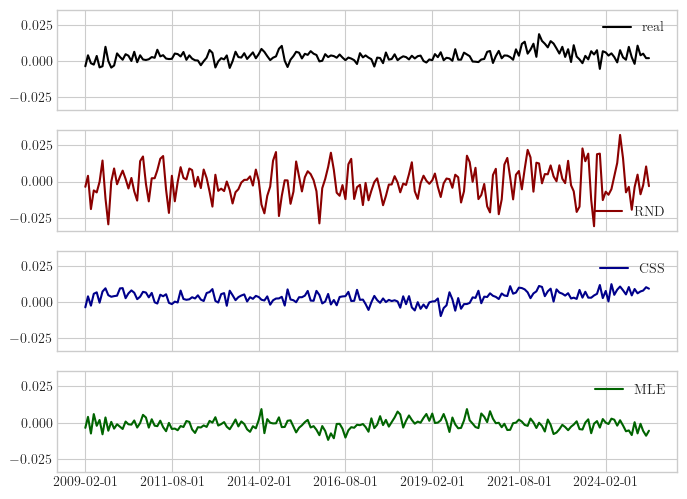

In [86]:
fig, axes = plt.subplots(4, 1, figsize=(8,6), sharex=True, sharey=True)
import pandas as pd
x_labels_year = pd.Series(dataset['t'][1:]).dt.date
x_labels_tick = x_labels_year.unique()[::30]

axes[0].plot(x_labels_year, dataset['pi_t'], linestyle='-', color='k', label='real')
axes[1].plot(x_labels_year, y_pred_0, linestyle='-', color='darkred', label='RND')
axes[2].plot(x_labels_year, y_pred_1, linestyle='-', color='darkblue', label='CSS')
axes[3].plot(x_labels_year, y_pred_2, linestyle='-', color='darkgreen', label='MLE')

for i in range(4):
    axes[i].legend()
    axes[i].set_xticks(x_labels_tick)
    axes[i].set_xticklabels(x_labels_tick, rotation=0)

plt.show()